# load dataset

In [1]:
! pip install corus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 176.2 kB/s eta 0:00:00


In [2]:
import pandas as pd
from corus import load_lenta

In [3]:
!wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

--2026-04-13 16:36:20--  https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/87156914/0b363e00-0126-11e9-9e3c-e8c235463bd6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-13T17%3A20%3A31Z&rscd=attachment%3B+filename%3Dlenta-ru-news.csv.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-13T16%3A20%3A28Z&ske=2026-04-13T17%3A20%3A31Z&sks=b&skv=2018-11-09&sig=Ui5YPYskaALqQq54yry0RIRDwQFbqtkcymV583A2cQI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NjEwMTc4MCwibmJmIjoxNzc2MDk4MTgwLCJwYXRoIjoicmVsZWFzZWFzc2V0

In [4]:
path = '/content/lenta-ru-news.csv.gz'
records = load_lenta(path)

In [5]:
data = []
for i, record in enumerate(records):
    data.append({
        'title': record.title,
        'text': record.text,
        'topic': record.topic
    })
    if i == 100000:
        break

In [6]:
df = pd.DataFrame(data)
df = df.dropna()
df.head()

,title,text,topic
0,Названы регионы России с самой высокой смертно...,Вице-премьер по социальным вопросам Татьяна Го...,Россия
1,Австрия не представила доказательств вины росс...,Австрийские правоохранительные органы не предс...,Спорт
2,Обнаружено самое счастливое место на планете,Сотрудники социальной сети Instagram проанализ...,Путешествия
3,В США раскрыли сумму расходов на расследование...,С начала расследования российского вмешательст...,Мир
4,Хакеры рассказали о планах Великобритании зами...,Хакерская группировка Anonymous опубликовала н...,Мир


In [7]:
# фильтр редких классов
topic_counts = df['topic'].value_counts()
df = df[df['topic'].isin(topic_counts[topic_counts >= 5].index)].copy()

# Preprocessing

In [8]:
! pip install razdel pymorphy3 nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 58.8 MB/s eta 0:00:00


In [9]:
import re
import requests
import nltk
import pymorphy3
import time
import gc
import tracemalloc
from razdel import tokenize
from nltk.stem import SnowballStemmer
from functools import lru_cache
from bs4 import BeautifulSoup
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [10]:
# Настройка препроцессинга
nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('russian'))

morph = pymorphy3.MorphAnalyzer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
URL_RE  = re.compile(r"(https?://\S+|www\.\S+)", re.IGNORECASE)
USER_RE = re.compile(r"@\w+")
NUM_RE  = re.compile(r"\b\d+([.,]\d+)?\b", re.UNICODE)
WS_RE   = re.compile(r"\s+", re.UNICODE)
WORD_RE = re.compile(r"^[a-zа-яё]+$", re.IGNORECASE)

USE_LEMMAS = True

In [12]:
def clean_html(text: str) -> str:
  soup = BeautifulSoup(text, 'html.parser')

  for tag in soup(['style', 'script']):
    tag.decompose()

  return " ".join(soup)

In [13]:
def normalize_text(s: str) -> str:
  s = s.lower()
  s = URL_RE.sub(" __url__ ", s)
  s = USER_RE.sub(" __user__ ", s)
  s = NUM_RE.sub(" __num__ ", s)
  s = WS_RE.sub(" ", s).strip()
  return s

In [14]:
@lru_cache(maxsize=100000)
def lemma_token_cached(token: str) -> str:
  if WORD_RE.match(token):
    return morph.parse(token)[0].normal_form
  return token

In [15]:
def tokenize_and_lemmatize(text: str):
  tokens = [token.text for token in tokenize(text)]
  if USE_LEMMAS:
    tokens = [lemma_token_cached(token) for token in tokens]
  return tokens

In [16]:
def preprocess_one(text: str) -> str:
  text = clean_html(text)
  text = normalize_text(text)

  tokens = tokenize_and_lemmatize(text)
  return " ".join(tokens)

In [17]:
def preprocess_corpus(texts):
    return np.array(
        [preprocess_one(str(t)) for t in tqdm(texts, desc="Processing texts")],
        dtype=object
    )

In [18]:
# разделение и кодирование таргетов
X = df['text']
y= df['topic']

In [19]:
#Разделение в соотношении 60/20/20
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [20]:
# применяем препроцессинг
X_train_pp = preprocess_corpus(X_train)
X_val_pp   = preprocess_corpus(X_val)
X_test_pp  = preprocess_corpus(X_test)

Processing texts: 100%|██████████| 20000/20000 [01:06<00:00, 300.18it/s]


# Обучение модели

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, accuracy_score, f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt

## TF-IDF

In [22]:
# Пайплайн для TfidfVectorizer
lr_tfidf = Pipeline(steps=[
    ("vect", TfidfVectorizer(
        sublinear_tf=False,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.5
    )),
    ("clf", LogisticRegression(
        C=float(np.float64(10.0)),
        max_iter=2000,
        n_jobs=-1
    ))
])

In [23]:
lr_tfidf.fit(X_train_pp, y_train)

Pipeline(steps=[('vect',
                 TfidfVectorizer(max_df=0.5, min_df=2, ngram_range=(1, 2))),
                ('clf', LogisticRegression(C=10.0, max_iter=2000, n_jobs=-1))])

## CountVectorizer

In [24]:
# Пайплайн для CountVectorizer
bow_pipe = Pipeline([
    ("vect", CountVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.7
    )),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=500,
        n_jobs=-1,
        class_weight="balanced",
        C=2.0
    ))
])

In [25]:
bow_pipe.fit(X_train_pp, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('vect',
                 CountVectorizer(max_df=0.7, min_df=3, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(C=2.0, class_weight='balanced',
                                    max_iter=500, n_jobs=-1, solver='saga'))])

In [36]:
def eval_model_multiclass(model, X_test, y_test, title="Model"):
    pred = model.predict(X_test)

    print(f"=== {title} ===")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("F1 macro:", f1_score(y_test, pred, average="macro"))
    print(classification_report(y_test, pred, digits=4))

    cm = confusion_matrix(y_test, pred)

    # Визуализация матрицы ошибок
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.show()

    return f1_score(y_test, pred, average="macro")

=== TF-IDF ===
Accuracy: 0.7354
F1 macro: 0.603863601965974


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                   precision    recall  f1-score   support

                      0.0000    0.0000    0.0000         3
   69-я параллель     0.8286    0.3558    0.4979       163
           Бизнес     0.6774    0.1579    0.2561       399
      Бывший СССР     0.9000    0.5617    0.6917      1362
              Дом     0.9233    0.4949    0.6444       681
         Из жизни     0.6758    0.7082    0.6916       980
   Интернет и СМИ     0.6295    0.7606    0.6889      1387
             Крым     0.5897    0.3459    0.4360       133
    Культпросвет      0.7778    0.1129    0.1972        62
         Культура     0.7839    0.8388    0.8104      1315
              Мир     0.7060    0.8731    0.7807      2885
  Наука и техника     0.6303    0.8654    0.7294      1129
      Путешествия     0.8814    0.4264    0.5747       645
           Россия     0.6323    0.7746    0.6962      3030
Силовые структуры     0.7315    0.5921    0.6544      1385
            Спорт     0.9609    0.9184    0.9392      2

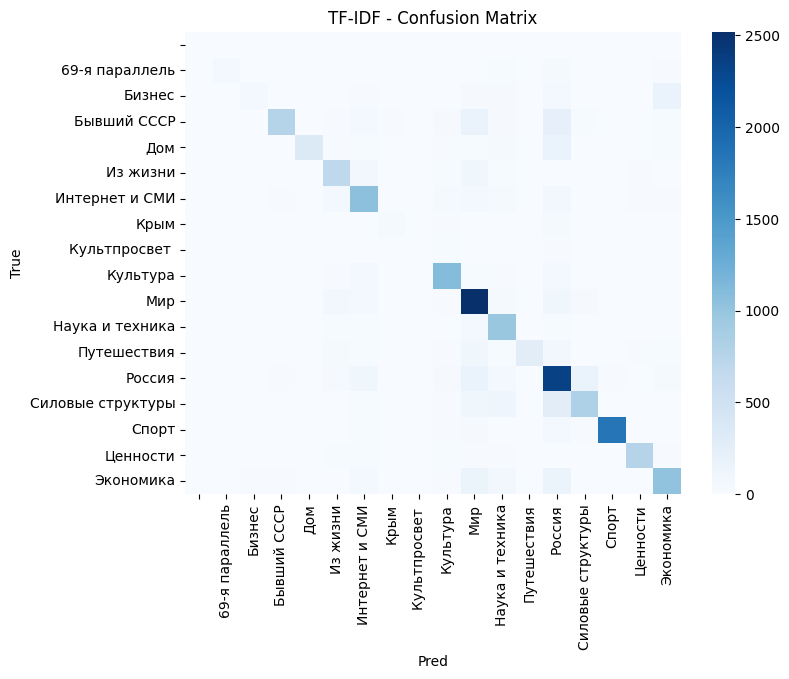

In [27]:
tfidf_proba = eval_model_multiclass(lr_tfidf, X_test, y_test, title='TF-IDF')

=== Count ===
Accuracy: 0.68965
F1 macro: 0.6069387651440695
                   precision    recall  f1-score   support

                      0.0000    0.0000    0.0000         3
   69-я параллель     0.5123    0.6380    0.5683       163
           Бизнес     0.4405    0.3434    0.3859       399
      Бывший СССР     0.8704    0.5426    0.6685      1362
              Дом     0.8311    0.5419    0.6560       681
         Из жизни     0.5003    0.7653    0.6051       980
   Интернет и СМИ     0.4848    0.7801    0.5980      1387
             Крым     0.4792    0.5188    0.4982       133
    Культпросвет      0.4333    0.4194    0.4262        62
         Культура     0.8335    0.6890    0.7544      1315
              Мир     0.7682    0.7075    0.7366      2885
  Наука и техника     0.7285    0.7343    0.7314      1129
      Путешествия     0.6691    0.5581    0.6086       645
           Россия     0.6332    0.6815    0.6565      3030
Силовые структуры     0.6053    0.6412    0.6227     

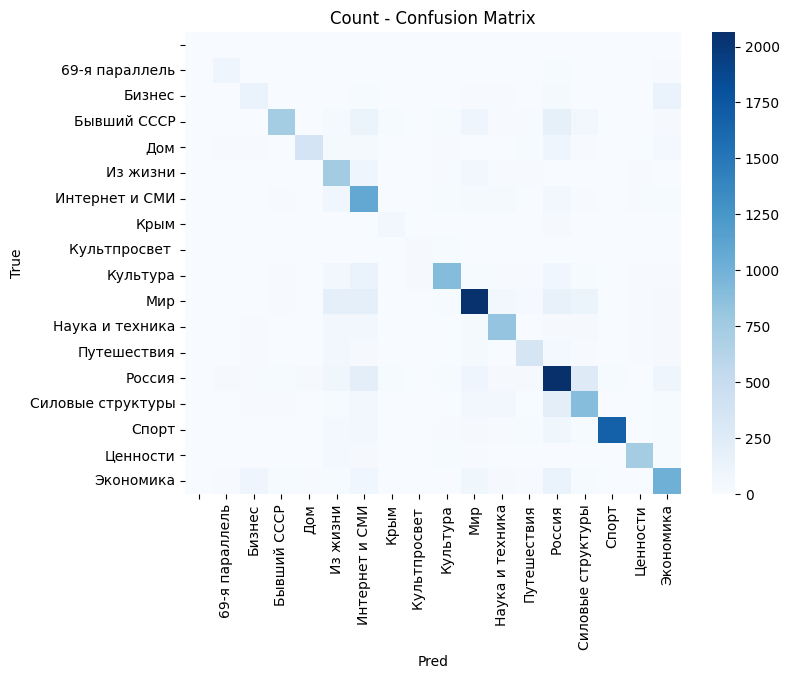

In [28]:
bow_proba = eval_model_multiclass(bow_pipe, X_test, y_test, title='Count')

# Улучшение качества

Подбор гиперпараметров

In [25]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer
from scipy.stats import loguniform
from joblib import Memory
import warnings
warnings.filterwarnings("ignore")

cache_dir = "/content/joblib_cache"
memory = Memory(cache_dir, verbose=0)

clf = LogisticRegression(
        solver="lbfgs",      # lbfgs обычно быстрее saga на плотных матрицах и стабильнее
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    )

## TF-IDF

In [26]:
# Пайплайн для TfidfVectorizer
tfidf_vec = TfidfVectorizer(max_features=20000)

tfidf_lr_pipe = Pipeline(
    steps=[
        ("vect", tfidf_vec),
        ("clf", clf),
    ],
    memory=memory
)

In [39]:
# Сетка параметров
param_dist = {
    "vect__ngram_range": [(1, 1), (1, 2)],
    "vect__min_df": [3, 5, 10],
    "vect__max_df": [0.7, 0.9],
    "clf__C": loguniform(1e-1, 1e1)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [42]:
# Запуск подбора гиперпараметров для TfidfVectorizer
rs_tfidf = RandomizedSearchCV(
    estimator=tfidf_lr_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    n_jobs=1,
    cv=cv,
    verbose=10,
    random_state=42,
    error_score='raise'
)

In [43]:
# Обучаем на предобработанных данных
rs_tfidf.fit(X_train_pp, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3; 1/20] START clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1)
[CV 1/3; 1/20] END clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1);, score=0.684 total time=  40.6s
[CV 2/3; 1/20] START clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1)
[CV 2/3; 1/20] END clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1);, score=0.681 total time=  38.9s
[CV 3/3; 1/20] START clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1)
[CV 3/3; 1/20] END clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1);, score=0.687 total time=  50.8s
[CV 1/3; 2/20] START clf__C=3.625617634576228, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 2)
[CV 1/3; 2/20] END clf__C=3.625617634576228, vect__max_df=0.7, vect__min_df=10, vect__ngram

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   error_score='raise',
                   estimator=Pipeline(memory=Memory(location=/content/joblib_cache/joblib),
                                      steps=[('vect',
                                              TfidfVectorizer(max_features=20000)),
                                             ('clf',
                                              LogisticRegression(max_iter=1000,
                                                                 n_jobs=-1,
                                                                 random_state=42))]),
                   n_iter=20, n_jobs=1,
                   param_distributions={'clf__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e7ebc2478c0>,
                                        'vect__max_df': [0.7, 0.9],
                                        'vect__min_df': [3, 5, 10],
                                        'vect__ngram_range': [(1, 1), (1, 2)]},
                   random_state=42, scoring='f1_macro', verbose=10)

In [44]:
best_C = rs_tfidf.best_params_["clf__C"]
best_min_df = rs_tfidf.best_params_['vect__min_df']

In [45]:
param_grid_fine = {
    "clf__C": [best_C * 0.5, best_C, best_C * 2],
    "vect__min_df": [max(1, best_min_df - 1), best_min_df, best_min_df + 1]
}

In [47]:
gs_tfidf = GridSearchCV(
    tfidf_lr_pipe,
    param_grid=param_grid_fine,
    scoring='f1_macro',
    cv=cv,
    verbose=10,
    n_jobs=1
)

gs_tfidf.fit(X_train_pp, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV 1/3; 1/9] START clf__C=3.2931446587915567, vect__min_df=4...................
[CV 1/3; 1/9] END clf__C=3.2931446587915567, vect__min_df=4;, score=0.744 total time=  53.1s
[CV 2/3; 1/9] START clf__C=3.2931446587915567, vect__min_df=4...................
[CV 2/3; 1/9] END clf__C=3.2931446587915567, vect__min_df=4;, score=0.748 total time=  58.1s
[CV 3/3; 1/9] START clf__C=3.2931446587915567, vect__min_df=4...................
[CV 3/3; 1/9] END clf__C=3.2931446587915567, vect__min_df=4;, score=0.742 total time=  56.0s
[CV 1/3; 2/9] START clf__C=3.2931446587915567, vect__min_df=5...................
[CV 1/3; 2/9] END clf__C=3.2931446587915567, vect__min_df=5;, score=0.743 total time=  51.9s
[CV 2/3; 2/9] START clf__C=3.2931446587915567, vect__min_df=5...................
[CV 2/3; 2/9] END clf__C=3.2931446587915567, vect__min_df=5;, score=0.748 total time= 1.0min
[CV 3/3; 2/9] START clf__C=3.2931446587915567, vect__min_df=5.........

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(memory=Memory(location=/content/joblib_cache/joblib),
                                steps=[('vect',
                                        TfidfVectorizer(max_features=20000)),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           n_jobs=-1,
                                                           random_state=42))]),
             n_jobs=1,
             param_grid={'clf__C': [np.float64(3.2931446587915567),
                                    np.float64(6.586289317583113),
                                    np.float64(13.172578635166227)],
                         'vect__min_df': [4, 5, 6]},
             scoring='f1_macro', verbose=10)

In [48]:
# Сохраняем лучшую модель
best_model_tfidf = gs_tfidf.best_estimator_

=== TF-IDF ===
Accuracy: 0.8505
F1 macro: 0.7655845121885707
                   precision    recall  f1-score   support

                      0.0000    0.0000    0.0000         3
   69-я параллель     0.9213    0.7178    0.8069       163
           Бизнес     0.6511    0.5238    0.5806       399
      Бывший СССР     0.8802    0.8686    0.8744      1362
              Дом     0.8698    0.8341    0.8516       681
         Из жизни     0.8258    0.7980    0.8116       980
   Интернет и СМИ     0.8295    0.8140    0.8217      1387
             Крым     0.7869    0.7218    0.7529       133
    Культпросвет      0.6316    0.3871    0.4800        62
         Культура     0.8751    0.9004    0.8876      1315
              Мир     0.8532    0.8867    0.8696      2885
  Наука и техника     0.8833    0.8919    0.8876      1129
      Путешествия     0.8776    0.8450    0.8610       645
           Россия     0.7965    0.8320    0.8139      3030
Силовые структуры     0.7754    0.7704    0.7729     

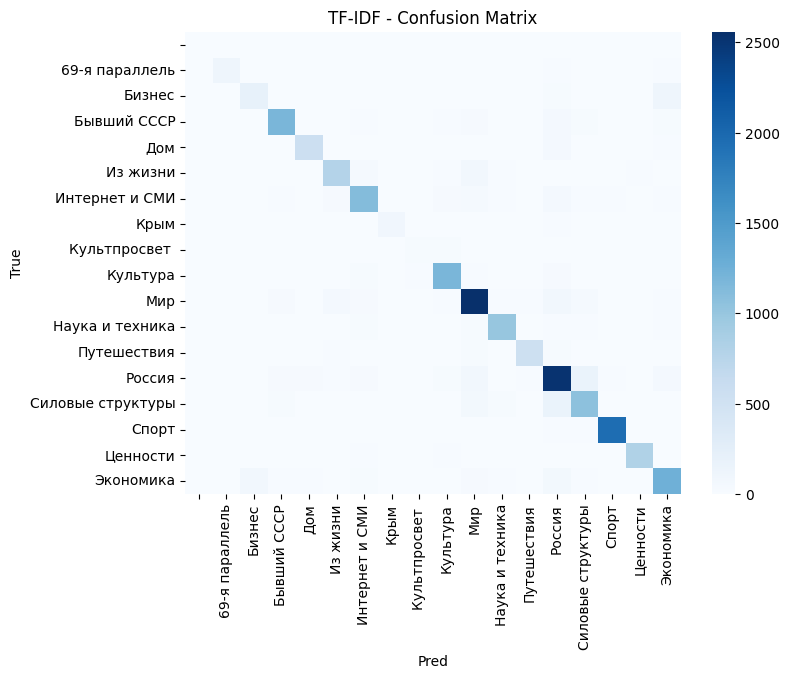

0.7655845121885707

In [49]:
eval_model_multiclass(best_model_tfidf, X_test_pp, y_test, title="TF-IDF")

## CountVectorizer

In [50]:
# Пайплайн для CountVectorizer
count_vec = CountVectorizer(max_features=20000)

count_lr_pipe = Pipeline(
    steps=[
        ("vect", count_vec),
        ("clf", clf),
    ],
    memory=memory
)

In [52]:
# Запуск подбора гиперпараметров для CountVectorizer
rs_count = RandomizedSearchCV(
    estimator=count_lr_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    n_jobs=1,
    cv=cv,
    verbose=10,
    random_state=42
)

rs_count.fit(X_train_pp, y_train)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV 1/3; 1/40] START clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1)
[CV 1/3; 1/40] END clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1);, score=0.744 total time=  53.6s
[CV 2/3; 1/40] START clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1)
[CV 2/3; 1/40] END clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1);, score=0.747 total time=  53.9s
[CV 3/3; 1/40] START clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1)
[CV 3/3; 1/40] END clf__C=0.5611516415334505, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1);, score=0.744 total time=  52.9s
[CV 1/3; 2/40] START clf__C=3.625617634576228, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 2)
[CV 1/3; 2/40] END clf__C=3.625617634576228, vect__max_df=0.7, vect__min_df=10, vect__ngra

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(memory=Memory(location=/content/joblib_cache/joblib),
                                      steps=[('vect',
                                              CountVectorizer(max_features=20000)),
                                             ('clf',
                                              LogisticRegression(max_iter=1000,
                                                                 n_jobs=-1,
                                                                 random_state=42))]),
                   n_iter=40, n_jobs=1,
                   param_distributions={'clf__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e7ebc2478c0>,
                                        'vect__max_df': [0.7, 0.9],
                                        'vect__min_df': [3, 5, 10],
                                        'vect__ngram_range': [(1, 1), (1, 2)]},
                   random_state=42, scoring='f1_macro', verbose=10)

In [53]:
best_C_count = rs_count.best_params_["clf__C"]

In [54]:
grid_count = GridSearchCV(
    rs_count.best_estimator_,
    {"clf__C": [best_C_count*0.5, best_C_count, best_C_count*2]},
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid_count.fit(X_train_pp, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(memory=Memory(location=/content/joblib_cache/joblib),
                                steps=[('vect',
                                        CountVectorizer(max_df=0.9,
                                                        max_features=20000,
                                                        min_df=3,
                                                        ngram_range=(1, 2))),
                                       ('clf',
                                        LogisticRegression(C=np.float64(0.1349283426801325),
                                                           max_iter=1000,
                                                           n_jobs=-1,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [np.float64(0.06746417134006626),
                                    np.float64(0.1349283426801325),
                                    np.float64(0.269856685360265)]},
             scoring='f1_macro')

In [55]:
# Сохраняем лучшую модель
best_model_count = grid_count.best_estimator_

=== COUNT ===
Accuracy: 0.85165
F1 macro: 0.7656593209928002
                   precision    recall  f1-score   support

                      0.0000    0.0000    0.0000         3
   69-я параллель     0.8849    0.7546    0.8146       163
           Бизнес     0.6280    0.5288    0.5741       399
      Бывший СССР     0.8865    0.8546    0.8703      1362
              Дом     0.8709    0.8517    0.8612       681
         Из жизни     0.8309    0.8071    0.8188       980
   Интернет и СМИ     0.8382    0.8104    0.8240      1387
             Крым     0.7928    0.6617    0.7213       133
    Культпросвет      0.6410    0.4032    0.4950        62
         Культура     0.8842    0.9004    0.8922      1315
              Мир     0.8500    0.8894    0.8692      2885
  Наука и техника     0.8847    0.8769    0.8808      1129
      Путешествия     0.8694    0.8465    0.8578       645
           Россия     0.7940    0.8446    0.8185      3030
Силовые структуры     0.7924    0.7718    0.7820     

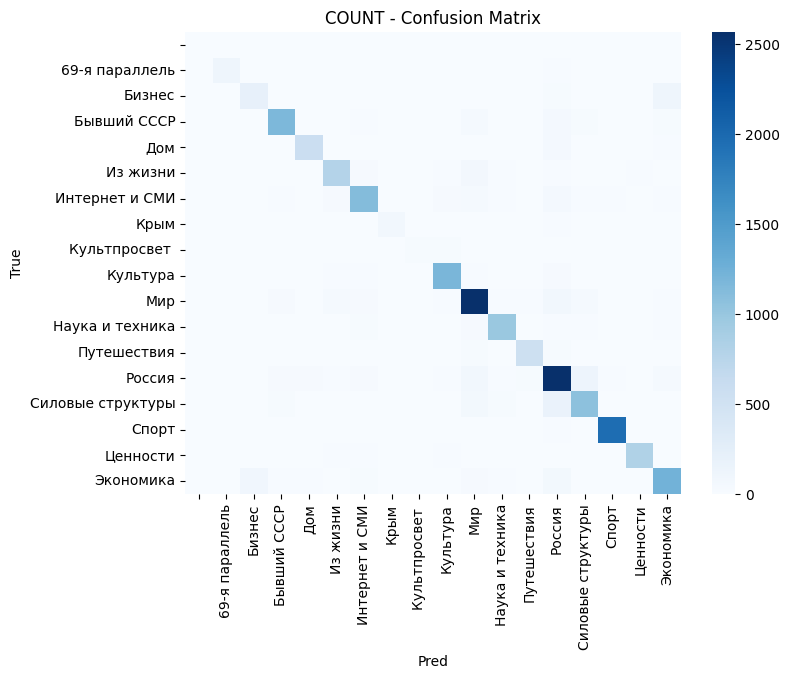

0.7656593209928002

In [56]:
eval_model_multiclass(best_model_count, X_test_pp, y_test, title="COUNT")

# Word2Vec

## gensim

In [21]:
! pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.8 MB/s eta 0:00:00


In [25]:
import gensim.downloader as api
import gensim.models
import spacy
import string
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

In [27]:
sentences_train = [text.split() for text in X_train_pp]

In [28]:
import time

start_time =time.time()

# Обучение Word2Vec

In [30]:
%%time

w2v_model = gensim.models.Word2Vec(
    sentences=sentences_train,
    vector_size=256, # default = 100
    window=7, # default = 5
    min_count=10,
    sg=1, # Training algorithm: 1 for skip-gram; otherwise CBOW
    negative=5, # If > 0, negative sampling will be used, if set to 0, no negative sampling is used.
    epochs=25, # Number of iterations (epochs) over the corpus
    seed=2023,
    workers=4
)
print(f"Обучение завершено за {time.time() - start_time:.2f} секунд")
print(f"Размер словаря: {len(w2v_model.wv)}")

Обучение завершено за 3096.30 секунд
Размер словаря: 30874
CPU times: user 1h 19min 58s, sys: 8.93 s, total: 1h 20min 6s
Wall time: 51min 6s


визуально оценим внутреннее (intrinsic) качество получившихся эмбеддингов, используя методы gensim - doesnt_match, most_similar

In [31]:
print("\n--- Оценка качества (Gensim methods) ---")
try:
    # most_similar
    similar = w2v_model.wv.most_similar('хакер', topn=3)
    print(f"Most similar to 'хакер': {similar}")

    # doesnt_match
    odd = w2v_model.wv.doesnt_match(['москва', 'париж', 'австрия', 'футбол'])
    print(f"Doesnt match ['москва', 'париж', 'австрия', 'футбол']: {odd}")
except KeyError as e:
    print(f"Слово не найдено в словаре: {e}")


--- Оценка качества (Gensim methods) ---
Most similar to 'хакер': [('взломать', 0.6366469860076904), ('взлом', 0.607935905456543), ('хакерский', 0.5860052704811096)]
Doesnt match ['москва', 'париж', 'австрия', 'футбол']: футбол


## Navec

Загрузим предобученные эмбеддинги из navec

In [32]:
%%capture
!pip install navec

In [33]:
from navec import Navec

In [35]:
!wget https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar

--2026-04-13 17:47:42--  https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26634240 (25M) [application/x-tar]
Saving to: ‘navec_news_v1_1B_250K_300d_100q.tar’

navec_news_v1_1B_25 100%[===================>]  25.40M  8.12MB/s    in 4.5s    

2026-04-13 17:47:48 (5.69 MB/s) - ‘navec_news_v1_1B_250K_300d_100q.tar’ saved [26634240/26634240]



In [36]:
path = 'navec_news_v1_1B_250K_300d_100q.tar'
navec = Navec.load(path)

## Классификация

Обучим модель sklearn.linear_model.LogisticRegression с обученными и загруженными эмбеддингами

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

In [38]:
# Функция для усреднения векторов (Mean Embedding)
def get_mean_embedding(texts, embeddings, dim):
  features = []
  for text in texts:
    words = text.split()
    vecs = [embeddings[w] for w in words if w in embeddings]

    if len(vecs) > 0:
      features.append(np.mean(vecs, axis=0))
    else:
      features.append(np.zeros(dim))
  return np.array(features)

In [44]:
# Признаки для W2V
dim_w2v = 256
X_train_w2v = get_mean_embedding(X_train_pp, w2v_model.wv, dim_w2v)
X_test_w2v  = get_mean_embedding(X_test_pp, w2v_model.wv, dim_w2v)

In [40]:
# Признаки для Navec
dim_navec = 300
X_train_navec = get_mean_embedding(X_train_pp, navec, dim_navec)
X_test_navec  = get_mean_embedding(X_test_pp, navec, dim_navec)

Обучение LogReg на W2V признаках

In [41]:
clf_w2v = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    n_jobs=1,
    C=5.0,
    random_state=42,
    verbose=10
)
clf_w2v.fit(X_train_w2v, y_train)

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   57.2s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   57.2s finished


LogisticRegression(C=5.0, max_iter=1000, n_jobs=1, random_state=42, verbose=10)

Обучение LogReg на Navec признаках

In [42]:
clf_navec = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    n_jobs=1,
    C=5.0,
    random_state=42,
    verbose=10
)
clf_navec.fit(X_train_navec, y_train)

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:  1.4min
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.4min finished


LogisticRegression(C=5.0, max_iter=1000, n_jobs=1, random_state=42, verbose=10)

# Итоговое сравнение всех моделей

Custom Word2Vec

In [46]:
pred_w2v = clf_w2v.predict(X_test_w2v)
f1_w2v = f1_score(y_test, pred_w2v, average='macro')

Navec

In [45]:
pred_navec = clf_navec.predict(X_test_navec)
f1_navec = f1_score(y_test, pred_navec, average='macro')

In [47]:
results = {
    "TF-IDF (Best)": 0.7655845121885707,
    "CountVect (Best)": 0.7656593209928002,
    "Custom W2V (256d)": f1_w2v,
    "Navec (Pretrained)": f1_navec
}

In [48]:
for name, score in results.items():
    print(f"{name:<20}: F1-macro = {score:.4f}")

TF-IDF (Best)       : F1-macro = 0.7656
CountVect (Best)    : F1-macro = 0.7657
Custom W2V (256d)   : F1-macro = 0.7158
Navec (Pretrained)  : F1-macro = 0.7052


TF-IDF и CountVectorizer показали схожие результаты (~0.76 F1-macro) и оказались лучше, чем эмбеддинги.